---
title: Bayesian Regularization
---

In [121]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import cvxpy as cp

### Recap: Ridge Regression

Let us first recap ridge regression from last lecture by considering one of the temperature anomalies datasets from last lecture. 

      year  month  value
0     1895      1   43.1
1     1895      2   37.4
2     1895      3   54.5
3     1895      4   63.4
4     1895      5   69.5
...    ...    ...    ...
1575  2026      4   67.0
1576  2026      5   70.5
1577  2026      6   77.8
1578  2026      7   81.7
1579  2026      8   81.7

[1580 rows x 3 columns]


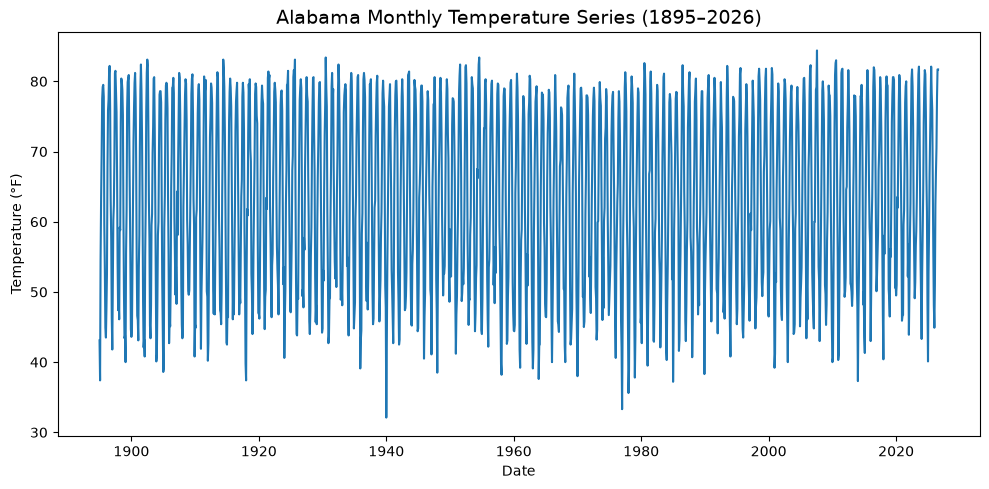

In [122]:
al_temp = pd.read_csv('cag_AL_tavg.csv')
print(al_temp)

# Create a datetime column for continuous time plotting
al_temp['date'] = pd.to_datetime(
    al_temp['year'].astype(str) + '-' + al_temp['month'].astype(str).str.zfill(2) + '-01'
)

# Plot monthly temperatures
plt.figure(figsize=(10, 5))
plt.plot(al_temp['date'], al_temp['value'])
plt.title('Alabama Monthly Temperature Series (1895–2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.tight_layout()
plt.show()


Instead of working with the raw temperature data, we shall we work with anomalies (relative to the 1901-2000 average). 

In [123]:
baseline_al = al_temp[(al_temp['year'] >= 1901) & (al_temp['year'] <= 2000)].groupby('month')['value'].mean()
al_temp['anomaly'] = (al_temp['value'] - al_temp['month'].map(baseline_al)) * 5/9
y = al_temp['anomaly']

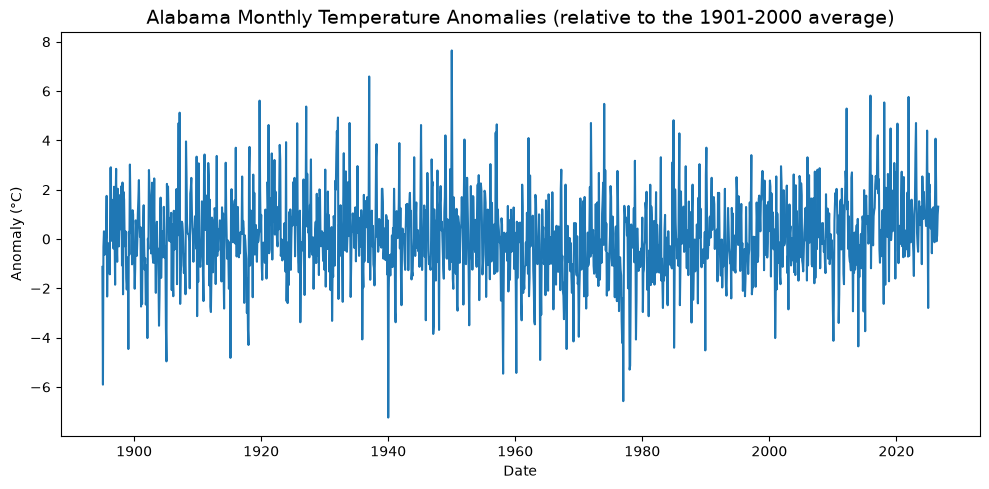

In [124]:
# Plot monthly temperatures
plt.figure(figsize=(10, 5))
plt.plot(al_temp['date'], al_temp['anomaly'])
plt.title('Alabama Monthly Temperature Anomalies (relative to the 1901-2000 average)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Anomaly (°C)')
plt.tight_layout()
plt.show()

We will fit our high-dimensional regression model: 
\begin{align*}
  y_t = \beta_0 + \beta_1 (t - 1) + \beta_2 (t - 2)_+ + \dots + \beta_{n-1}(t - (n-1))_+ + \epsilon_t
\end{align*}
to this dataset. This can be written in the usual regression form as $y = X \beta + \epsilon$ with the $X$ matrix calculated as follows. 

In [125]:
n = len(y)
print(n)
x = np.arange(1, n + 1, dtype=float)
knots = np.arange(1, n)                       # c = 1, ..., n-1  (c = 1 gives the x-1 column)
X = np.column_stack([np.ones(n), np.maximum(x[:, None] - knots, 0)])
print(X)

1580
[[1.000e+00 0.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 1.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 2.000e+00 1.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [1.000e+00 1.577e+03 1.576e+03 ... 1.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 1.578e+03 1.577e+03 ... 2.000e+00 1.000e+00 0.000e+00]
 [1.000e+00 1.579e+03 1.578e+03 ... 3.000e+00 2.000e+00 1.000e+00]]


Ridge regression is given by the minimizer of: 
\begin{align*}
   \|y - X \beta\|^2 + \lambda \sum_{j=2}^{n-1} \beta_j^2
\end{align*}
where $\lambda$ is the tuning parameter. Small $\lambda$ leads to fitted values close to the data (overfitting) and large $\lambda$ leads to fitted values coming from a straight line (underfitting). We used the following code for computing the ridge estimator for fixed $\lambda$ (note that, instead of using this code, we can also use the formula derived in Lecture 12: $(X^T X + \lambda J)^{-1} X^T y$ to compute the ridge estimator). 


In [126]:
def solve_ridge(X, y, lambda_val, penalty_start=2):
    n, p = X.shape
    
    # Define variable
    beta = cp.Variable(p)
    
    # Define objective
    loss = cp.sum_squares(X @ beta - y)
    reg = lambda_val * cp.sum_squares(beta[penalty_start:])
    objective = cp.Minimize(loss + reg)
    
    # Solve problem
    prob = cp.Problem(objective)
    prob.solve(solver = cp.CLARABEL)
    
    return beta.value

Instead of the above function which use cvxpy, we can directly compute the ridge estimator using the formula: $(X^T X + \lambda J)^{-1} X^T y$. Here $J$ is the diagonal matrix with first two diagonal entries 0 and all other diagonal entries equal to 1. 

In [127]:
def solve_ridge_formula(X, y, lambda_val, penalty_start=2):
    n, p = X.shape
    J = np.diag(np.r_[np.zeros(penalty_start), np.ones(p - penalty_start)])
    return np.linalg.solve(X.T @ X + lambda_val * J, X.T @ y)

The code below can be used to check that both these approaches give the same estimator. 

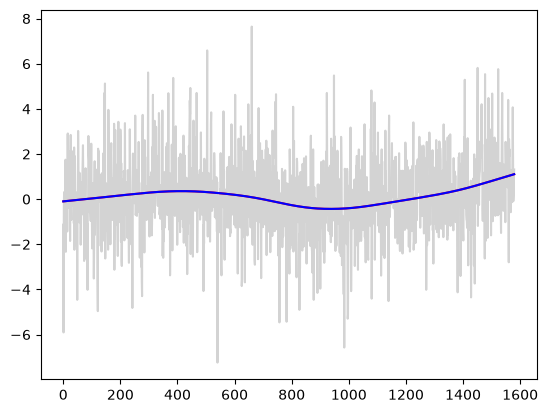

In [128]:
lambda_value = 1e8
b_ridge_cvxpy = solve_ridge(X, y, lambda_val = lambda_value)
b_ridge_formula = solve_ridge_formula(X, y, lambda_val = lambda_value)
plt.plot(y, color = 'lightgray')
ridge_fitted_cvxpy = np.dot(X, b_ridge_cvxpy)
ridge_fitted_formula = np.dot(X, b_ridge_formula)
plt.plot(ridge_fitted_cvxpy, color = 'red', label = 'CVX solution')
plt.plot(ridge_fitted_formula, color = 'blue', label = 'Formula solution')
plt.show()

One important aspect in ridge regression is the choice of the regularization parameter $\lambda$. For this, the first step is to identify two values $\lambda_{\min}$ and $\lambda_{\max}$ which serve as the two extreme ends for $\lambda$. When $\lambda = \lambda_{\min}$, the fitted values are basically the same as the raw data, while when $\lambda = \lambda_{\max}$, the fitted values coincide with a simple line fit. 

Using the above code, we can check that when $\lambda = 10^{-2}$, the fitted values are basically the same as the raw data; and when $\lambda = 10^{11}$, the fitted values coincide with linear regression. So we take $\lambda_{\min} := 10^{-2}$ and $\lambda_{max} = 10^{11}$. 

Then we take a grid of $\lambda$ by taking $\log \lambda$ values to be equally spaced between $\log \lambda_{\min}$ and $\log \lambda_{\max}$. 

In [129]:
lambda_min = 1e-2
lambda_max = 1e11
lambda_candidates =  np.logspace(np.log10(lambda_min), np.log10(lambda_max), num=14)
print(lambda_candidates)

[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07
 1.e+08 1.e+09 1.e+10 1.e+11]


To choose $\lambda$, we used cross-validation (CV) in the last lecture via the following code. 

In [130]:
def ridge_cv(X, y, lambda_candidates):
    n = len(y)
    k = 5
    fold_size = n // k
    folds = []

    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size if i < k - 1 else n  # last fold includes remainder
        test_indices = np.arange(start, end)
        train_indices = np.concatenate([np.arange(0, start), np.arange(end, n)])
        folds.append((train_indices, test_indices))

    cv_errors = {lamb: 0 for lamb in lambda_candidates}

    for train_index, test_index in folds:
        X_train = X[train_index]
        X_test = X[test_index]
        y_train = y[train_index]
        y_test = y[test_index]

        for lamb in lambda_candidates:
            beta = solve_ridge_formula(X_train, y_train, lambda_val=lamb)
            y_pred = np.dot(X_test, beta)
            squared_errors = (y_test - y_pred) ** 2
            cv_errors[lamb] += np.sum(squared_errors)

    for lamb in lambda_candidates:
        cv_errors[lamb] /= n

    best_lambda = min(cv_errors, key=cv_errors.get)
    return best_lambda, cv_errors


In [131]:
best_lambda, cv_errors = ridge_cv(X, y, lambda_candidates)
print(best_lambda)
for lamb, error in sorted(cv_errors.items()):
    print(f"Lambda = {lamb:.2f}, CV Error = {error:.6f}")


100000000.0
Lambda = 0.01, CV Error = 129699.733663
Lambda = 0.10, CV Error = 86557.405815
Lambda = 1.00, CV Error = 22373.552499
Lambda = 10.00, CV Error = 2646.339789
Lambda = 100.00, CV Error = 303.444306
Lambda = 1000.00, CV Error = 27.187489
Lambda = 10000.00, CV Error = 16.733096
Lambda = 100000.00, CV Error = 11.931114
Lambda = 1000000.00, CV Error = 4.639443
Lambda = 10000000.00, CV Error = 3.038500
Lambda = 100000000.00, CV Error = 2.849374
Lambda = 1000000000.00, CV Error = 2.917165
Lambda = 10000000000.00, CV Error = 2.957611
Lambda = 100000000000.00, CV Error = 2.978341


Below we calculate the ridge estimator for $\lambda$ chosen to be the best $\lambda$ given by CV:

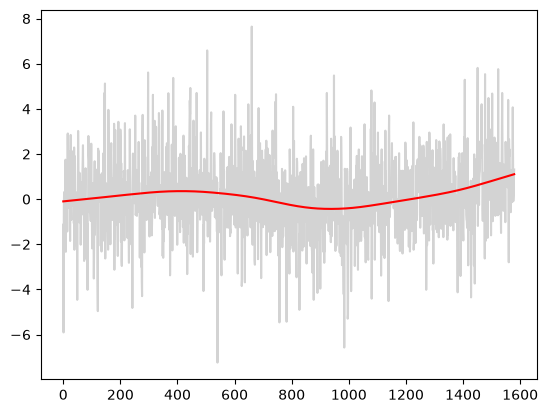

In [132]:
b_ridge = solve_ridge_formula(X, y, lambda_val = best_lambda) 
plt.plot(y, color = 'lightgray')
ridge_fitted = np.dot(X, b_ridge)
plt.plot(ridge_fitted, color = 'red')
plt.show()

Next we shall use Bayesian regularization for selecting $\lambda$. 

### Bayesian Regularization

We work with the following prior: 
\begin{align*}
   \beta_0, \beta_1 \overset{\text{i.i.d}}{\sim} N(0, C) ~~ \text{ and } ~~ \beta_2, \dots, \beta_{n-1} \overset{\text{i.i.d}}{\sim} N(0, \sigma^2/\lambda). 
\end{align*}
We also treat $\sigma$ and $\lambda$ as unknown parameters and assign the prior: 
\begin{align*}
   \lambda \sim f_{\lambda}(\lambda) ~~ \text{ and } ~~ \log \sigma \sim \text{unif}(-C, C)
\end{align*}
where
\begin{align*}
   f_{\lambda}(\lambda) \propto \frac{I(\lambda_{\min} \leq \lambda \leq \lambda_{\max})}{\lambda} ~\text{ which corresponds to}~ \log \lambda \sim \text{unif}(\log \lambda_{\min}, \log \lambda_{\max}). 
\end{align*}
The posterior of $\beta, \sigma, \lambda$ then becomes: 
\begin{align*}
   \beta \mid \text{data}, \sigma, \lambda \sim N\left((X^TX + \lambda J)^{-1} X^T y, \sigma^2 (X^T X + \lambda J)^{-1} \right)
\end{align*}
and
\begin{align*}
   \frac{1}{\sigma^2} \mid \text{data}, \lambda \sim \text{Gamma} \left(\frac{n}{2} - 1, \frac{y^T y - y^T X(X^T X + \lambda J)^{-1} X^T y}{2} \right). 
\end{align*}
and
\begin{align*}
  f_{\lambda\mid\text{data}}(\lambda) \propto f_{\lambda}(\lambda) \frac{\lambda^{(n-2)/2}|X^TX+\lambda J|^{-1/2}}
  {\left(y^Ty-y^TX(X^TX+\lambda J)^{-1}X^Ty\right)^{(n/2)-1}}
\end{align*}
The key here is the posterior for $\lambda$. We compute this posterior numerically below by taking a grid of values for $\log \lambda$. The computation proceeds more stably if we evaluate the posterior density of $\log \lambda$: 
\begin{align*}
   f_{\log \lambda \mid \text{data}}(x) \propto \frac{e^{(n/2 - 1)x} |X^T X + e^x J|^{-1/2}}{\left( y^T y - y^T X (X^TX + e^x J)^{-1} X^T y \right)^{n/2 - 1}} I\{\log \lambda_{\min} \leq x \leq \log \lambda_{\max}\}. 
\end{align*}


In [134]:
n = len(y)
J = np.diag(np.concatenate([[0, 0], np.ones(n - 2)]))
XTX, XTy, yTy = X.T @ X, X.T @ y, y.T @ y

loglambda_gr = np.linspace(np.log(lambda_min), np.log(lambda_max), 1000)
logpost_loglambda = np.zeros(len(loglambda_gr))

for i, ell in enumerate(loglambda_gr):
    if i % 50 == 0: print(i)

    Mat = XTX + np.exp(ell) * J
    beta_mean = np.linalg.solve(Mat, XTy)
    sgn, logdet = np.linalg.slogdet(Mat)

    logpost_loglambda[i] = (
        (n/2-1) * ell
        - 0.5 * logdet
        - (n/2 - 1) * np.log(yTy - XTy.T @ beta_mean)
    )

post_loglambda = np.exp(logpost_loglambda - np.max(logpost_loglambda))

# Probability weights: these sum to 1.
prob_loglambda = post_loglambda / np.sum(post_loglambda)

# Density values: their integral is approximately 1.
step = loglambda_gr[1] - loglambda_gr[0]
post_loglambda = prob_loglambda / step

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950


Below is the posterior for $\log \lambda$: 

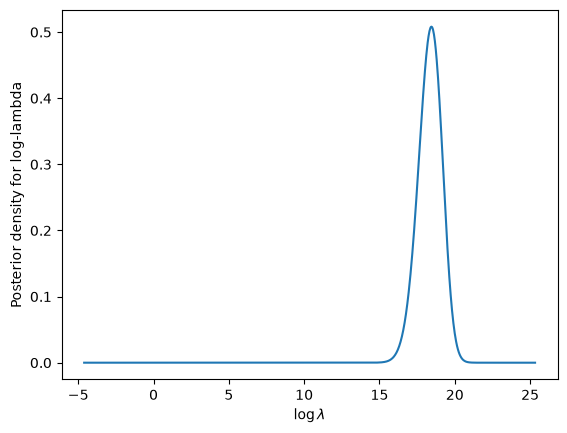

In [136]:
plt.figure()
plt.plot(loglambda_gr, post_loglambda)
plt.xlabel(r"$\log\lambda$")
plt.ylabel("Posterior density for log-lambda")
plt.show()

Below we take logs with base 10 for better comparison with the previous set of $\lambda$'s.'

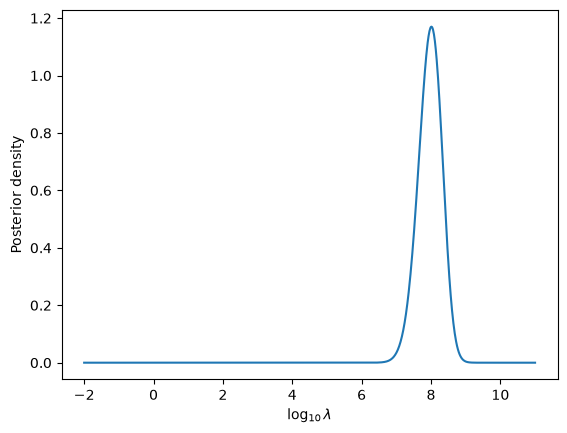

In [137]:
plt.figure()
plt.plot(loglambda_gr / np.log(10), post_loglambda * np.log(10))
plt.xlabel(r"$\log_{10}\lambda$")
plt.ylabel("Posterior density")
plt.show()

Using this posterior, we can compute posterior mean and mode for $\lambda$: 

In [138]:
lambda_gr = np.exp(loglambda_gr)

mean_lambda = np.sum(lambda_gr * prob_loglambda)
sd_lambda = np.sqrt(np.sum((lambda_gr - mean_lambda)**2 * prob_loglambda))

cdf_lambda = np.cumsum(prob_loglambda)
lower, median_lambda, upper = lambda_gr[
    np.searchsorted(cdf_lambda, [0.025, 0.5, 0.975])
]

print(f"Posterior mean: {mean_lambda:.3e}")
print(f"Posterior standard deviation: {sd_lambda:.3e}")
print(f"Posterior median: {median_lambda:.3e}")
print(f"95% credible interval: ({lower:.3e}, {upper:.3e})")

Posterior mean: 1.228e+08
Posterior standard deviation: 1.013e+08
Posterior median: 9.572e+07
95% credible interval: (1.788e+07, 3.914e+08)


We can visualize the fitted curves when $\lambda$ is taken to be the posterior mean and the posterior mode

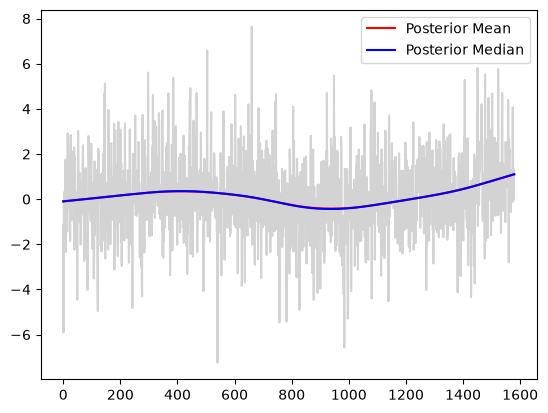

In [140]:
b_ridge_mean = solve_ridge_formula(X, y, lambda_val = mean_lambda)
b_ridge_median = solve_ridge_formula(X, y, lambda_val = median_lambda)
plt.plot(y, color = 'lightgray')
ridge_fitted_mean = np.dot(X, b_ridge_mean)
ridge_fitted_median = np.dot(X, b_ridge_median)
plt.plot(ridge_fitted_mean, color = 'red', label = 'Posterior Mean')
plt.plot(ridge_fitted_median, color = 'blue', label = 'Posterior Median')
plt.legend()
plt.show()

For full uncertainty quantification, we can generate posterior samples from the full posterior of $(\beta, \lambda, \sigma)$. This is done in the following way: first sample from the numerical discrete posterior from $\log \lambda$ (leading to a sample of $\lambda$), use this sample of $\lambda$ to obtain a sample from $\sigma$, then use the two values of $\lambda, \sigma$ to sample from $\beta$. 

In [142]:
N = 1000
n = len(y)

J = np.diag(np.concatenate([[0, 0], np.ones(n - 2)]))
XTX, XTy, yTy = X.T @ X, X.T @ y, y.T @ y
shape = n/2 - 1

loglambda_samples = np.random.choice(
    loglambda_gr, size=N, p=prob_loglambda
)
lambda_samples = np.exp(loglambda_samples)

sig_samples = np.zeros(N)
betahats = np.zeros((n, N))
muhats = np.zeros((n, N))

for i in range(N):
    if i % 50 == 0: print(i)

    lam = lambda_samples[i]
    Mat = XTX + lam * J
    norm_mean = np.linalg.solve(Mat, XTy)

    # Sample sigma: numpy uses the Gamma shape and scale.
    rate = (yTy - XTy.T @ norm_mean) / 2
    sig = np.sqrt(1 / np.random.gamma(shape, 1/rate))
    sig_samples[i] = sig

    # Sample beta with covariance sig**2 * Mat^{-1}.
    L = np.linalg.cholesky(Mat)
    betahat = norm_mean + sig * np.linalg.solve(L.T, np.random.randn(n))

    betahats[:, i] = betahat
    muhats[:, i] = X @ betahat

beta_est = np.mean(betahats, axis=1)
mu_est = np.mean(muhats, axis=1)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950


The posterior samples corresponding to the fitted curves are plotted below. Here by fitted curve, we mean: 
\begin{align*}
  \mu_t^{(i)} = \beta^{(i)}_0 + \beta^{{i}}_1 (t - 1) + \sum_{j=2}^{n-1} \beta^{(i)}_j(t - j)_+
\end{align*}
where $\beta^{(i)}_j, j = 0, 1, \dots, n-1$ is the $i$-th posterior sample. 

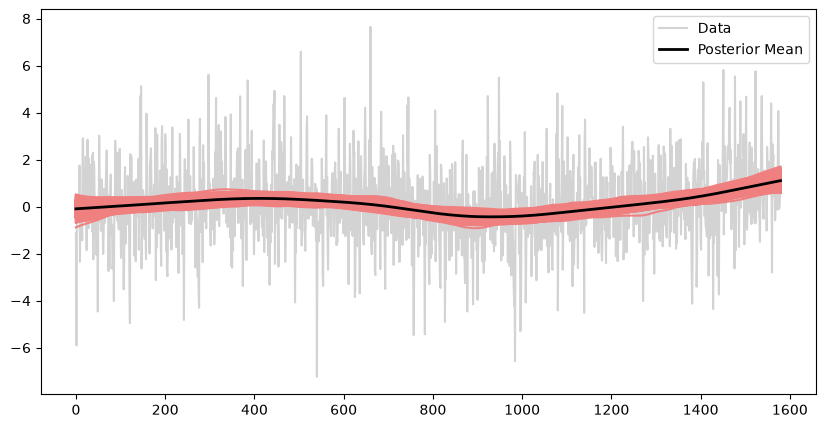

In [143]:
plt.figure(figsize=(10, 5))

plt.plot(y, label="Data", color="lightgray", zorder=1)

for i in range(N):
    plt.plot(muhats[:, i], color="lightcoral", zorder=2)

plt.plot(mu_est, color="black", linewidth=2,
         label="Posterior Mean", zorder=3)

plt.legend()
plt.show()

We can also visualize the posterior $\sigma$ values:

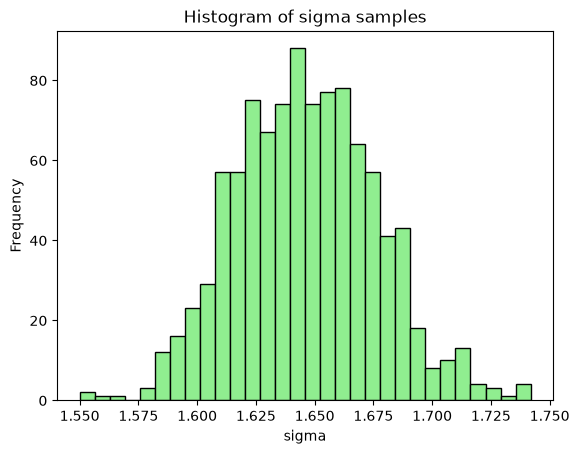

In [144]:
plt.hist(sig_samples, bins=30, color='lightgreen', edgecolor='black')
plt.title('Histogram of sigma samples')
plt.xlabel('sigma')
plt.ylabel('Frequency')
plt.show()